<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/food_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Vision

## Check the GPU
Google Colab offer free GPU, however not all of them are compatible with `mixed precision training`

[Google Colab offers](https://developer.nvidia.com/cuda-gpus):

* K80(not compatible)
* P100(not compatible)
* Tesla T4(compatible)

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-859b420f-121c-6f18-979e-bc811257a874)


## Use TensorFlow Dataset to download data

In [2]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt


In [3]:
# list the available dataset
dataset_list = tfds.list_builders()
print('food101' in dataset_list) # it's a very long list so just check if your dataset is exist

True


In [ ]:
# load the dataset
(train_data, test_data), ds_info = tfds.load(name='food101',
                                             split=['train', 'validation'],
                                             as_supervised= True, # data get return in key value per(Tuple)
                                             shuffle_files=True,
                                             with_info=True)

# Exploring the food1001 data from TensorFlow Datasets
To become one with our data we want to find:
* Class names
* The shape of our input data (image tensore)
* The data type of our input data
* What the labels look like(e.g. are they one-hot encoded or are they label encoded)
* Do the label mutch up with the class names?

In [5]:
# Feature of food101 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [6]:
# Get the class names
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [7]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [8]:
# Take one sample of the train data
train_one_sample = train_data.take(1) # samples are in the form of (image_tensor, label)
# What does one sample of our training data looks like
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [9]:
# Output info about our training data
for image, label in train_one_sample:
  print(f"""
        Image shape: {image.shape}
        Image datatype: {image.dtype}
        Target classe from food100(tensor form): {label}
        Class name(str form):  {class_names[label.numpy()]}
  """)


        Image shape: (512, 512, 3)
        Image datatype: <dtype: 'uint8'>
        Target classe from food100(tensor form): 30
        Class name(str form):  deviled_eggs
  


In [10]:
# What does our image data from TFDS looks like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 28,  31,  50],
        [ 27,  30,  49],
        [ 21,  23,  44],
        ...,
        [ 17,  28,  60],
        [ 20,  30,  65],
        [ 28,  38,  73]],

       [[ 11,  14,  33],
        [ 23,  26,  45],
        [ 24,  26,  47],
        ...,
        [ 39,  50,  82],
        [ 33,  44,  76],
        [ 19,  30,  62]],

       [[ 16,  17,  37],
        [ 23,  24,  44],
        [ 19,  20,  40],
        ...,
        [ 45,  56,  86],
        [ 39,  50,  80],
        [ 36,  47,  77]],

       ...,

       [[148,  94, 117],
        [153,  99, 122],
        [153, 102, 121],
        ...,
        [ 94, 128, 166],
        [ 96, 130, 168],
        [ 96, 131, 169]],

       [[143,  89, 112],
        [151,  97, 120],
        [153, 102, 121],
        ...,
        [102, 134, 173],
        [103, 135, 174],
        [101, 135, 173]],

       [[145,  91, 114],
        [154, 100, 123],
        [158, 107, 126],
        ...,
        [105, 137, 17

In [11]:
# What are the min and max values of our image tensor?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image form Tensorflow Dataset

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

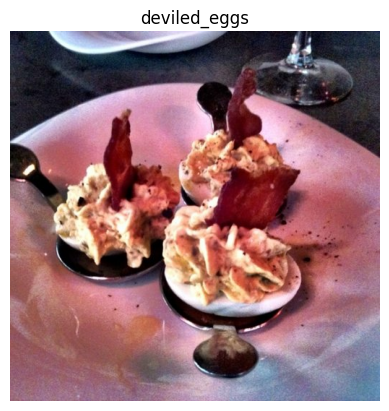

In [12]:
# Plot an image
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False)

## Preprocess the data
Neural Network work best when the data is in certain way. e.g (Normalized, batched, and etc). However not all data including `Tensorflow Dataset` comes like this.

What we know about our data:
* It's in `unit8`
* Comprised of all diffirent size tensors (diffirent size of images)
* It's not scaled, the pixel values are between 0 and 255
What a model like:
* Data in `float32` dtype(or for mixed percision `float16` and `float32`)
* For `batches`, Tensorflow likes all of the tensors within a batch to be of the same size
* `Scaled`(Values between 0 and 1) also called normalization tensors perform better

Since we're going to use `EfficientNetBX` pretrained model from keras application we don't need to rescale our data(these architecture have rescalling build-in)

And Since we are not using `image_dataset_from_directory` we need the following steps:
* Make sure all the training and testing dataset has the same `shape`
* Covert the dtype of image tensors from `uint8` to `float32`
* We need to `normalize` the dataset
* Make sure our data is `Shuffled` during the training process
* Create `batches`


In [69]:
# Make a function for prepocessing the image
def preprocess_img(image, label, img_shape=224):
  """
  Convert image data type from `uint8` -> `float32` and reshape image to [img_shape, img_shape, color_channels]
  """
  image = tf.image.resize(image, size=[img_shape, img_shape]) # Reshape the target image
  # image = image/255. # rescale the image is not require in efficiennetbx from tensorflow dataset
  return tf.cast(image, tf.float32), label # Return (float32_image, label) tuple


In [71]:
# Prprocess a single sample image and check the output
take_one_image =train_data.take(1)
image, label = next(iter(take_one_image))
preprocess_img_data = preprocess_img(image, label)
print(f'Image data befor preprocessing: \n  {image[2]} ....., \n Shape: {image.shape}\n Datatype: {image.dtype}')
print(f'Image data after preprocessing: \n  {preprocess_img_data[:2]} ....., \n Shape: {preprocess_img_data[0].shape}\n Datatype: {preprocess_img_data[0].dtype}')



Image data befor preprocessing: 
  [[20  7  0]
 [25 12  4]
 [31 18 10]
 ...
 [40 21  4]
 [40 21  4]
 [39 22  4]] ....., 
 Shape: (512, 512, 3)
 Datatype: <dtype: 'uint8'>
Image data after preprocessing: 
  (<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[2.52448978e+01, 1.22448978e+01, 4.72959232e+00],
        [3.24081612e+01, 1.94081631e+01, 1.14081631e+01],
        [3.27193871e+01, 1.97193871e+01, 1.07193871e+01],
        ...,
        [3.90050926e+01, 2.09948616e+01, 3.49997830e+00],
        [3.63112297e+01, 1.93112297e+01, 2.11736846e+00],
        [3.64132767e+01, 2.00000343e+01, 4.00003481e+00]],

       [[1.98979568e+01, 6.89795780e+00, 1.83672667e-01],
        [2.89438782e+01, 1.59438782e+01, 7.94387770e+00],
        [2.21122437e+01, 9.11224365e+00, 1.11224365e+00],
        ...,
        [4.88979416e+01, 2.70152836e+01, 6.14283562e+00],
        [4.46428452e+01, 2.38520279e+01, 3.07144165e+00],
        [4.27602005e+01, 2.19540844e+01, 3.07142830e+00]],

       [[2.0